In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

/tmp/ipykernel_2221337/2795012682.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["100k", "500k", "1m", "5m", "10m"], fontsize=10)
/tmp/ipykernel_2221337/2795012682.py:75: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
/tmp/ipykernel_2221337/2795012682.py:78: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 10000)


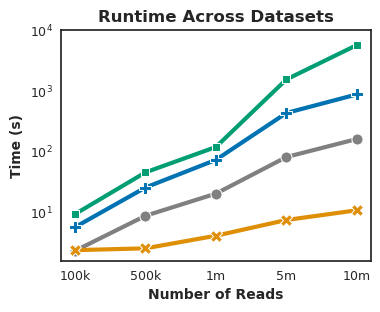

In [21]:
import matplotlib.ticker as ticker


# directories = ['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads']
directories = ['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads']

def plot_times_across_folders(folder_list):

    # --- Config / ordering ---
    col_to_tool = {
        "BT2_Time": "bowtie2 (no variant calling)",
        "BT2_LoFreq_Time": "lofreq",
        "BT2_iVar_Time": "ivar",
        "Bronko_Time": "bronko"
    }
    tool_order = ["bowtie2 (no variant calling)", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    tmp_palette = ["gray", base_palette[1], base_palette[2], base_palette[0]]
    palette = dict(zip(tool_order, tmp_palette))

    # --- Load data in folder order (preserve order on x-axis) ---
    rows = []
    for folder in folder_list:
        path = os.path.join(folder, "sample_1/overview.tsv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        # ensure columns exist and coerce to numeric (missing -> NaN)
        entry = {"folder": folder}
        for col in col_to_tool:
            entry[col] = pd.to_numeric(df.get(col, [pd.NA]).iloc[0], errors="coerce")
        rows.append(entry)

    if not rows:
        print("No overview.tsv files found.")
        return

    combined = pd.DataFrame(rows)

    # --- Long format with explicit mapping ---
    df_long = combined.melt(id_vars="folder", value_vars=list(col_to_tool.keys()),
                            var_name="col", value_name="Time")
    df_long["Tool"] = df_long["col"].map(col_to_tool)
    df_long = df_long.dropna(subset=["Time"])  # drop missing times

    # force folder and tool ordering
    df_long["folder"] = pd.Categorical(df_long["folder"], categories=folder_list, ordered=True)
    df_long["Tool"] = pd.Categorical(df_long["Tool"], categories=tool_order, ordered=True)

    # --- Plot ---
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.lineplot(
        data=df_long,
        x="folder",
        y="Time",
        hue="Tool",
        style="Tool",
        markers=True,
        dashes=False,
        palette=palette,
        ax=ax,
        linewidth=3,
        markersize=8
    )

    ax.set_title("Runtime Across Datasets", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Reads", fontsize=10, fontweight="bold")
    ax.set_xticklabels(["100k", "500k", "1m", "5m", "10m"], fontsize=10)
    ax.set_ylabel("Time (s)", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9, pad=0)
    ax.tick_params(axis="y", labelsize=9, pad=0)
    ax.legend(title="", fontsize=9)
    ax.set_yscale("log")
    ax.set_ylim(bottom=0)
    ax.set_xticks(ax.get_xticks())  # ensure x-axis ticks exist
    ax.get_legend().remove()
    ax.set_ylim(0, 10000)


plot_times_across_folders(directories)


/tmp/ipykernel_2221337/1837666305.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["100k", "500k", "1m", "5m"], fontsize=10)
/tmp/ipykernel_2221337/1837666305.py:76: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


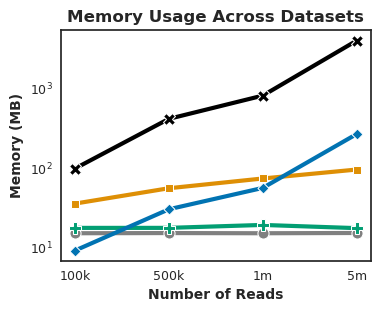

In [ ]:
import matplotlib.ticker as ticker


directories = ['100k_reads_mem', '500k_reads_mem', '1m_reads_mem', '5m_reads_mem', '10m_reads_mem']

def plot_memory_across_folders(folder_list):

    # --- Config / ordering ---
    col_to_tool = {
        "BT2_Mem": "bowtie2 (no variant calling)",
        "Samtools_Mem": "samtools", 
        "BT2_LoFreq_Mem": "lofreq",
        "BT2_iVar_Mem": "ivar",
        "Bronko_Mem": "bronko"
    }
    tool_order = ["bowtie2 (no variant calling)", "samtools", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    tmp_palette = ["gray", "black", base_palette[1], base_palette[2], base_palette[0]]
    palette = dict(zip(tool_order, tmp_palette))

    # --- Load data in folder order (preserve order on x-axis) ---
    rows = []
    for folder in folder_list:
        path = os.path.join(folder, "sample_1/overview.tsv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        # ensure columns exist and coerce to numeric (missing -> NaN)
        entry = {"folder": folder}
        for col in col_to_tool:
            entry[col] = pd.to_numeric(df.get(col, [pd.NA]).iloc[0], errors="coerce")
        rows.append(entry)

    if not rows:
        print("No overview.tsv files found.")
        return

    combined = pd.DataFrame(rows)

    # --- Long format with explicit mapping ---
    df_long = combined.melt(id_vars="folder", value_vars=list(col_to_tool.keys()),
                            var_name="col", value_name="Time")
    df_long["Tool"] = df_long["col"].map(col_to_tool)
    df_long = df_long.dropna(subset=["Time"])  # drop missing times

    # force folder and tool ordering
    df_long["folder"] = pd.Categorical(df_long["folder"], categories=folder_list, ordered=True)
    df_long["Tool"] = pd.Categorical(df_long["Tool"], categories=tool_order, ordered=True)

    # --- Plot ---
    sns.set_theme(style="white")
    fig, ax = plt.subplots(figsize=(4, 3))
    # df_long = df_long[df_long["Tool"] != "ivar"]
    sns.lineplot(
        data=df_long,
        x="folder",
        y="Time",
        hue="Tool",
        style="Tool",
        markers=True,
        dashes=False,
        palette=palette,
        ax=ax,
        linewidth=3,
        markersize=8
    )

    ax.set_title("Memory Usage Across Datasets", fontsize=12, fontweight="bold")
    ax.set_xlabel("Number of Reads", fontsize=10, fontweight="bold")
    ax.set_xticklabels(["100k", "500k", "1m", "5m"], fontsize=10)
    ax.set_ylabel("Memory (MB)", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelsize=9, pad=0)
    ax.tick_params(axis="y", labelsize=9, pad=0)
    ax.legend(title="", fontsize=9)
    ax.set_yscale("log")
    ax.set_ylim(bottom=0)
    ax.set_xticks(ax.get_xticks())  # ensure x-axis ticks exist
    ax.get_legend().remove()

plot_memory_across_folders(directories)
